In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
lane = 4
motion = np.load(f'data/processed_data/motion/lane{lane}/2024-07-09.npy')
sm = np.load('2024-07-09_sm.npy')

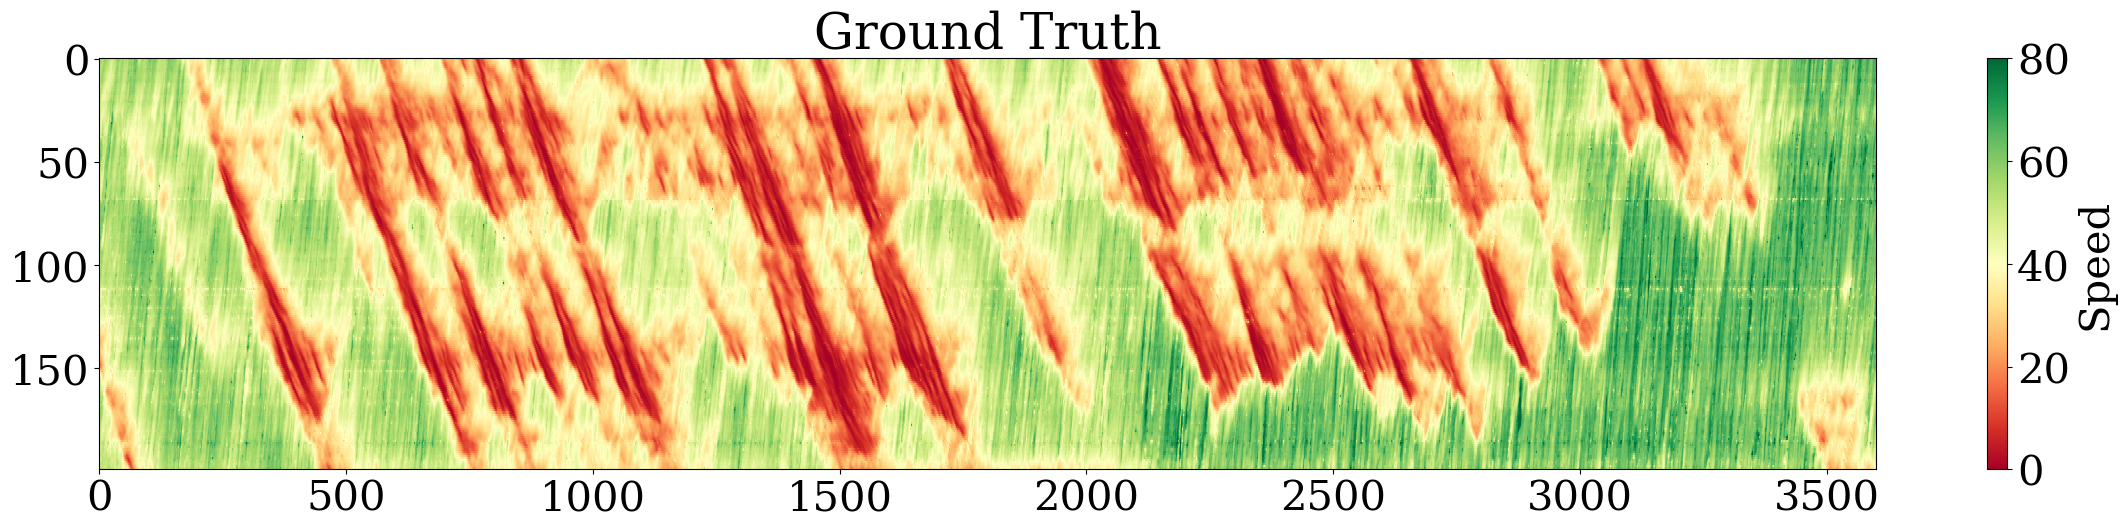

In [3]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(motion, cmap='RdYlGn', interpolation='nearest', origin='lower',vmin=0, vmax=80, aspect='auto')
plt.colorbar(label='Speed')
plt.title('Ground Truth')
plt.tight_layout()
# reverse y-axis to match the original plot
plt.gca().invert_yaxis()
plt.savefig(f'figures/smoothed_speed_MOTION_lane{lane}.pdf', dpi=300, bbox_inches='tight')
plt.show()

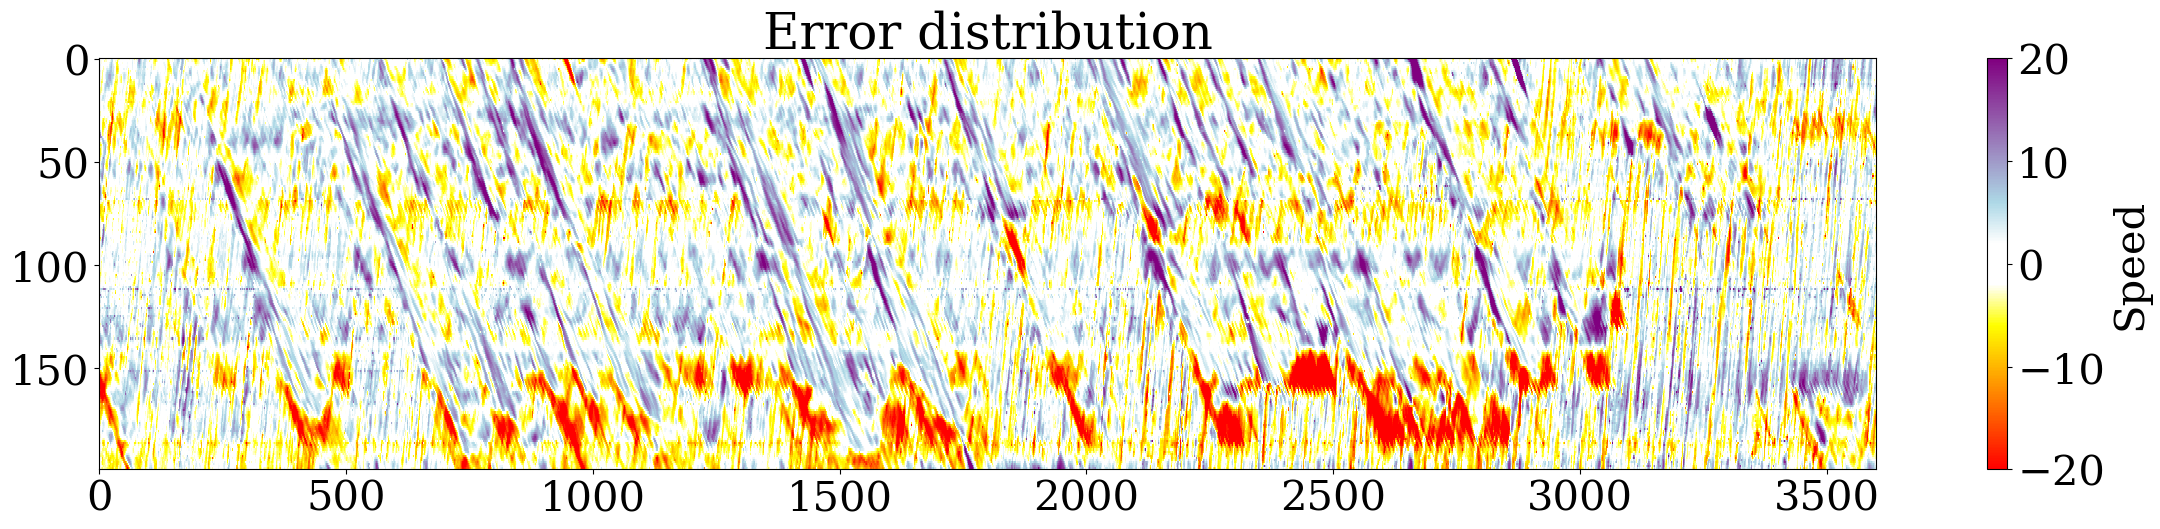

In [4]:
lane = 4
motion = np.load(f'data/processed_data/motion/lane{lane}/2024-07-09.npy')
sm = np.load('2024-07-09_sm_4.npy')
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
colors = ['red','yellow','white', 'white', 'white','lightblue','purple']
nodes = [0, 0.35,0.45,0.5,0.55,0.65, 1]  # Normalized nodes
cmap = LinearSegmentedColormap.from_list('custom', list(zip(nodes, colors)))
plt.imshow(sm-motion, cmap=cmap, interpolation='nearest', origin='lower',vmin=-20, vmax=20, aspect='auto')
plt.colorbar(label='Speed')
plt.title('Error distribution')
plt.tight_layout()
# reverse y-axis to match the original plot
plt.gca().invert_yaxis()
plt.savefig('figures/error_4.pdf', dpi=300, bbox_inches='tight')
plt.show()

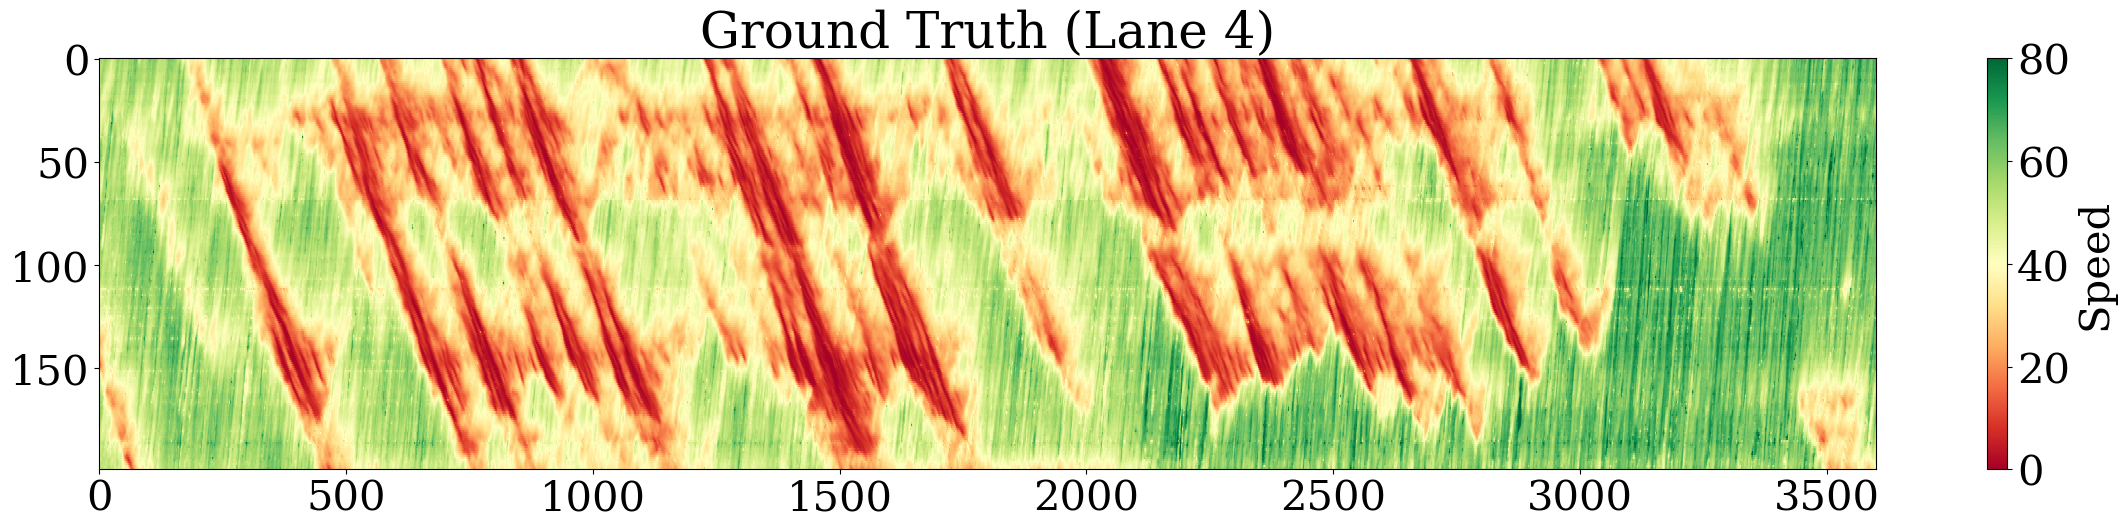

In [5]:
lane = 4
motion = np.load(f'data/processed_data/motion/lane{lane}/2024-07-09.npy')
# sm = np.load('2024-07-09_sm_4.npy')
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(motion, cmap='RdYlGn', interpolation='nearest', origin='lower',vmin=0, vmax=80, aspect='auto')
plt.colorbar(label='Speed')
plt.title('Ground Truth (Lane 4)')
plt.tight_layout()
# reverse y-axis to match the original plot
plt.gca().invert_yaxis()
plt.savefig('figures/motion_lane4.pdf', dpi=300, bbox_inches='tight')
plt.show()

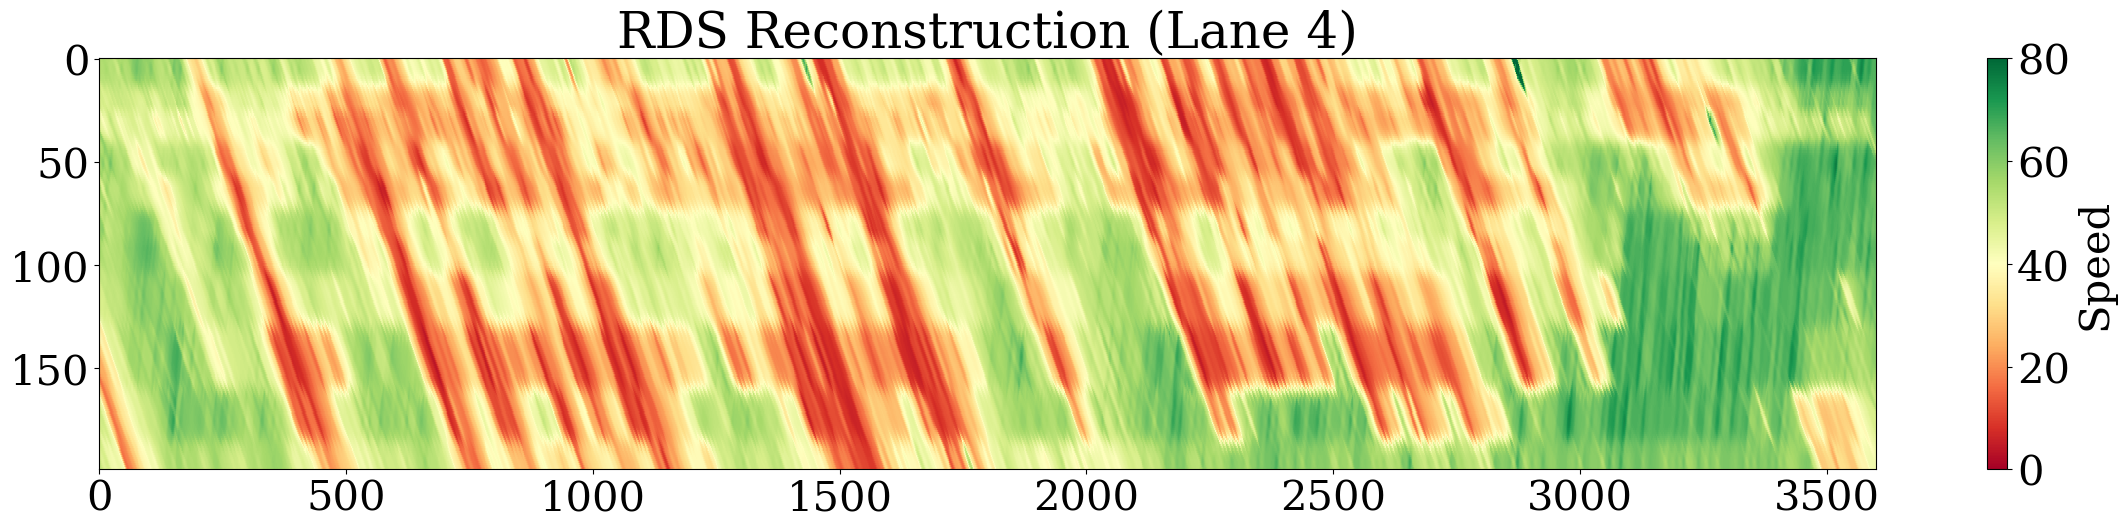

In [6]:
lane = 4
# motion = np.load(f'data/processed_data/motion/lane{lane}/2024-07-09.npy')
sm = np.load('2024-07-09_sm_4.npy')
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(sm, cmap='RdYlGn', interpolation='nearest', origin='lower',vmin=0, vmax=80, aspect='auto')
plt.colorbar(label='Speed')
plt.title('RDS Reconstruction (Lane 4)')
plt.tight_layout()
# reverse y-axis to match the original plot
plt.gca().invert_yaxis()
plt.savefig('figures/rds_lane_4.pdf', dpi=300, bbox_inches='tight')
plt.show()

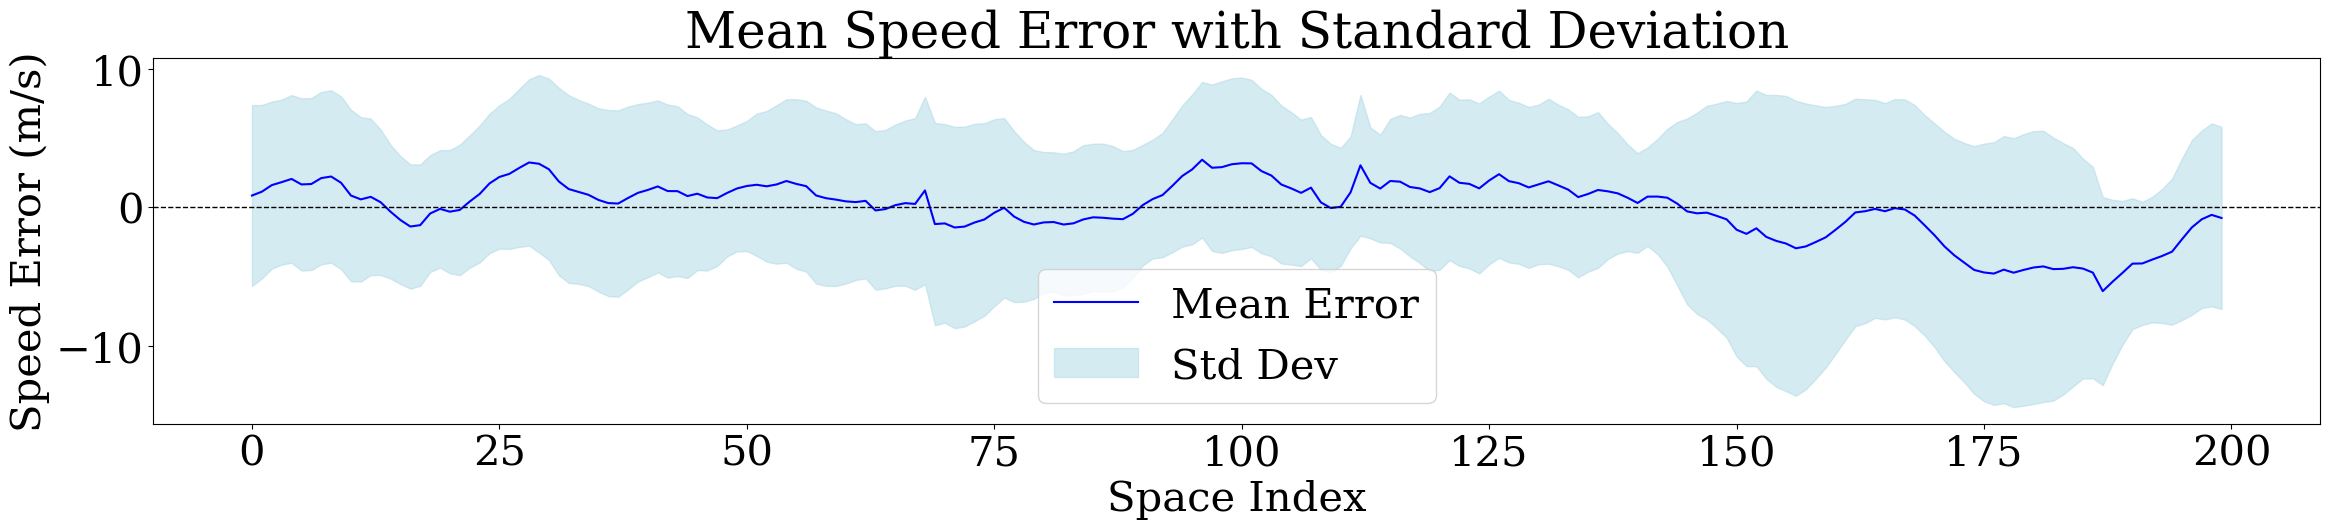

In [7]:
# show the error distribution along th y-axis
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.plot(np.mean(sm - motion, axis=1), label='Mean Error', color='blue')
plt.fill_between(range(sm.shape[0]), 
                 np.mean(sm - motion, axis=1) - np.std(sm - motion, axis=1), 
                 np.mean(sm - motion, axis=1) + np.std(sm - motion, axis=1), 
                 color='lightblue', alpha=0.5, label='Std Dev')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Space Index')
plt.ylabel('Speed Error (m/s)')
plt.title('Mean Speed Error with Standard Deviation')
plt.legend()
plt.tight_layout()